<a href="https://colab.research.google.com/github/seeuni0320/AI-ML/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
import numpy as np
import matplotlib.pyplot as plt

from copy import deepcopy

from sklearn.preprocessing import (
    add_dummy_feature,
    PolynomialFeatures,
    StandardScaler,
)
from sklearn.linear_model import (
    LinearRegression,
    SGDRegressor,
    Ridge,
    Lasso,
    ElasticNet,
)
from sklearn.model_selection import learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

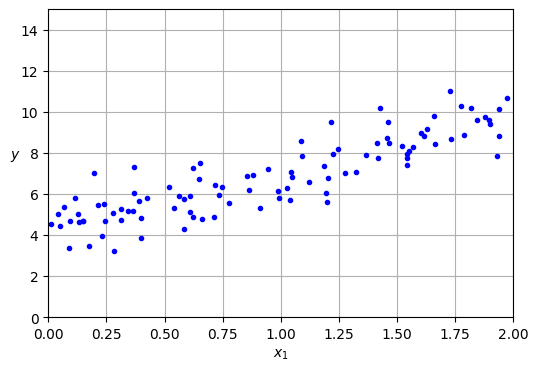

In [74]:
np.random.seed(42)

m = 100
X = 2 * np.random.rand(m, 1)
y = 4 + 3 * X + np.random.randn(m, 1)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

In [75]:
X_b = add_dummy_feature(X)   # 각 샘플 앞에 x0 = 1 추가
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[4.21509616],
       [2.77011339]])

In [76]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best

y_predict

array([[4.21509616],
       [9.75532293]])

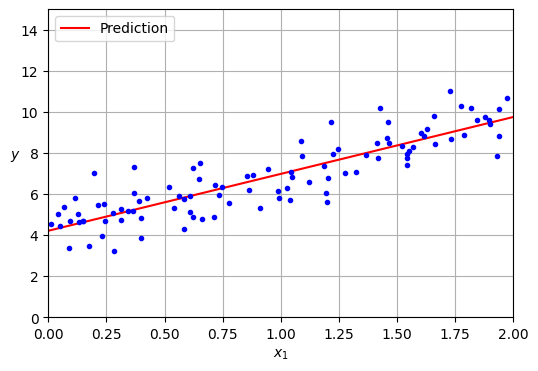

In [77]:
plt.figure(figsize=(6, 4))
plt.plot(X_new, y_predict, "r-", label="Prediction")
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")
plt.show()

In [78]:
lin_reg = LinearRegression()
lin_reg.fit(X, y)

lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [79]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

In [80]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.21509616],
       [2.77011339]])

In [81]:
np.linalg.pinv(X_b) @ y

array([[4.21509616],
       [2.77011339]])

In [82]:
eta = 0.1
n_epochs = 1000
m = len(X_b)

np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients

theta

array([[4.21509616],
       [2.77011339]])

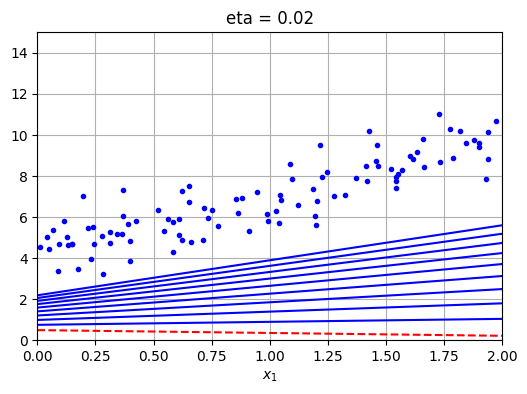

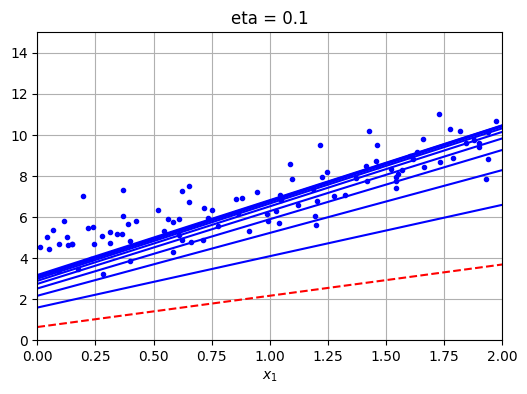

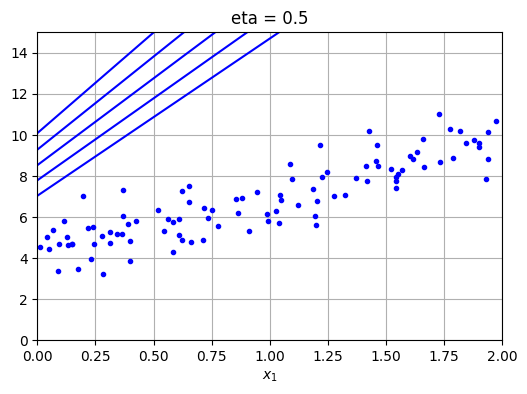

In [83]:
def plot_gradient_descent(theta, eta, X, y, n_steps=20):
    m = len(X)
    plt.plot(X, y, "b.")
    for step in range(n_steps):
        if step < 10:
            X_new = np.array([[0], [2]])
            X_new_b = add_dummy_feature(X_new)
            y_predict = X_new_b @ theta
            style = "b-" if step > 0 else "r--"
            plt.plot(X_new, y_predict, style)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()

np.random.seed(42)
theta_path_bgd = []

for eta in (0.02, 0.1, 0.5):
    theta = np.random.randn(2, 1)
    plt.figure(figsize=(6, 4))
    plot_gradient_descent(theta, eta, X, y)
    plt.title(f"eta = {eta}")
    plt.show()

In [84]:
n_epochs = 50
t0, t1 = 5, 50   # 학습 스케줄 하이퍼파라미터

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

theta

array([[4.21076011],
       [2.74856079]])

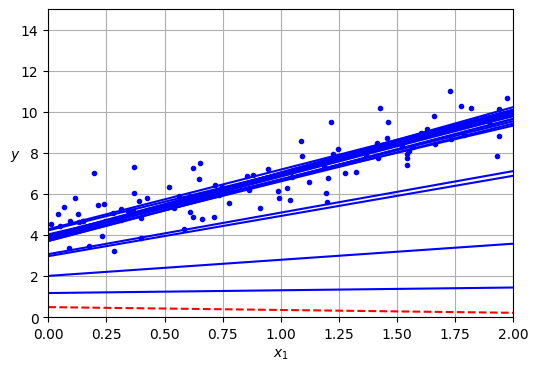

In [85]:
np.random.seed(42)
theta = np.random.randn(2, 1)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")

for step in range(20):
    random_index = np.random.randint(m)
    xi = X_b[random_index : random_index + 1]
    yi = y[random_index : random_index + 1]

    X_new = np.array([[0], [2]])
    X_new_b = add_dummy_feature(X_new)
    y_predict = X_new_b @ theta
    style = "b-" if step > 0 else "r--"
    plt.plot(X_new, y_predict, style)

    gradients = 2 * xi.T @ (xi @ theta - yi)
    eta = learning_schedule(step)
    theta = theta - eta * gradients

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

In [86]:
sgd_reg = SGDRegressor(
    max_iter=1000,
    tol=1e-5,
    penalty=None,
    eta0=0.01,
    n_iter_no_change=100,
    random_state=42,
)

sgd_reg.fit(X, y.ravel())
sgd_reg.intercept_, sgd_reg.coef_

(array([4.21278812]), array([2.77270267]))

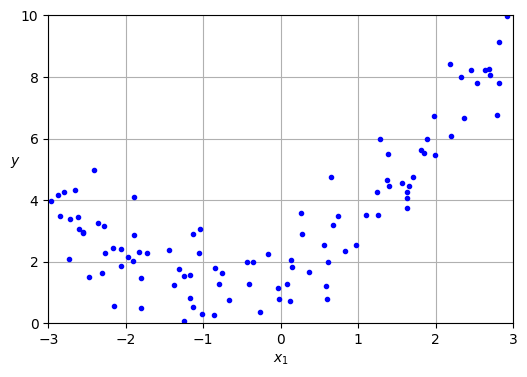

In [87]:
np.random.seed(42)

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

In [88]:
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

X[0], X_poly[0]

(array([-0.75275929]), array([-0.75275929,  0.56664654]))

In [89]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

lin_reg.intercept_, lin_reg.coef_

(array([1.78134581]), array([[0.93366893, 0.56456263]]))

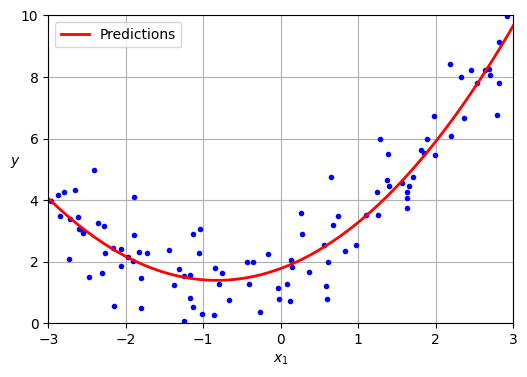

In [90]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


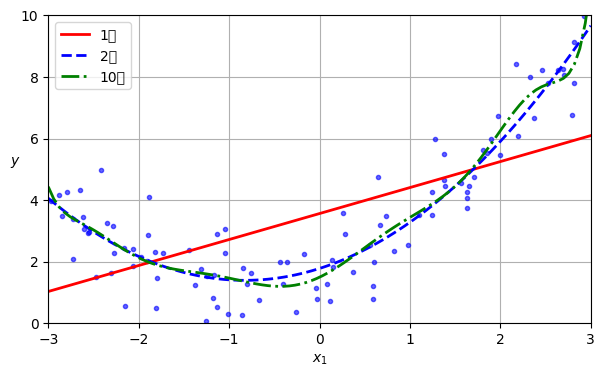

In [91]:
plt.figure(figsize=(7, 4))
plt.plot(X, y, "b.", alpha=0.6)

for degree, style, label in [
    (1, "r-", "1차"),
    (2, "b--", "2차"),
    (10, "g-.", "10차"),
]:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(),
    )
    model.fit(X, y)
    y_new = model.predict(X_new)
    plt.plot(X_new, y_new, style, linewidth=2, label=label)

plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

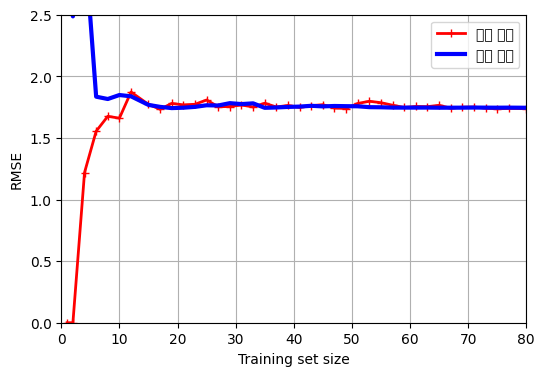

In [92]:
train_sizes, train_scores, valid_scores = learning_curve(
    LinearRegression(),
    X,
    y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_root_mean_squared_error",
)

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="훈련 세트")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="검증 세트")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54984 (\N{HANGUL SYLLABLE HUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47144 (\N{HANGUL SYLLABLE RYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

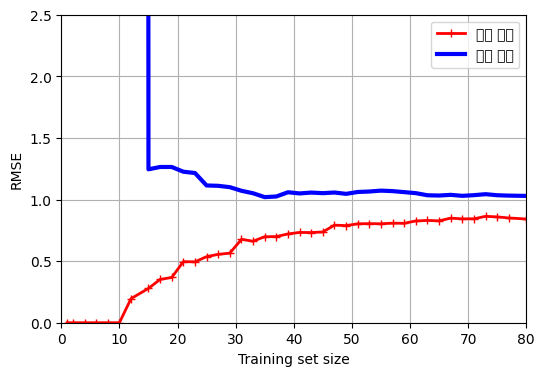

In [93]:
polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False),
    LinearRegression(),
)

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression,
    X,
    y,
    train_sizes=np.linspace(0.01, 1.0, 40),
    cv=5,
    scoring="neg_root_mean_squared_error",
)

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.figure(figsize=(6, 4))
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="훈련 세트")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="검증 세트")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.grid()
plt.legend(loc="upper right")
plt.axis([0, 80, 0, 2.5])
plt.show()

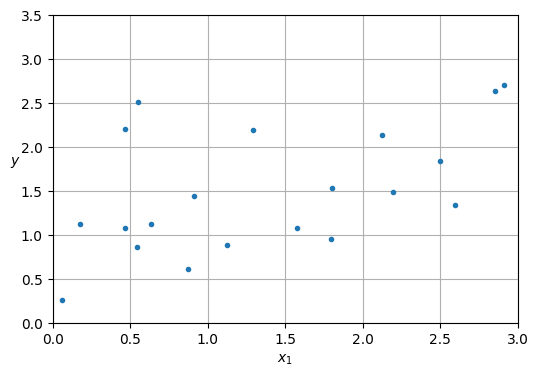

In [94]:
np.random.seed(42)

m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [95]:
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.55325833])

In [96]:
sgd_reg = SGDRegressor(
    penalty="l2",
    alpha=0.1 / m,
    tol=None,
    max_iter=1000,
    eta0=0.01,
    random_state=42,
)

sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([1.55302613])

In [97]:
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

In [98]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.54333232])

In [99]:
np.random.seed(42)

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(
    PolynomialFeatures(degree=90, include_bias=False),
    StandardScaler(),
)

X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)

sgd_reg = SGDRegressor(
    penalty=None,
    eta0=0.002,
    random_state=42,
)

n_epochs = 500
best_valid_rmse = float("inf")
best_model = None
train_errors, val_errors = [], []

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)

    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = np.sqrt(mean_squared_error(y_valid, y_valid_predict))

    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = np.sqrt(mean_squared_error(y_train, y_train_predict))

    val_errors.append(val_error)
    train_errors.append(train_error)

best_valid_rmse

np.float64(1.4099344710854789)

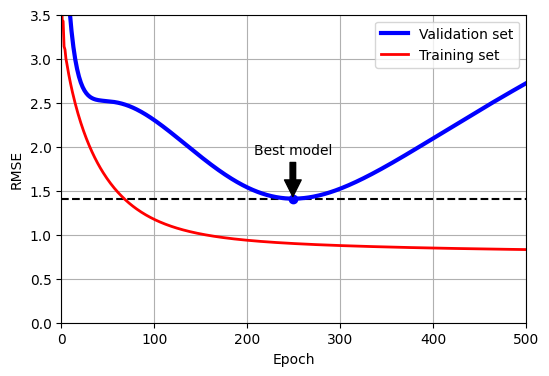

In [100]:
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model', xy=(best_epoch, best_valid_rmse),xytext = (best_epoch, best_valid_rmse + 0.5), ha="center", arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k--")
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r-", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0,n_epochs, 0, 3.5])
plt.grid()
plt.show()

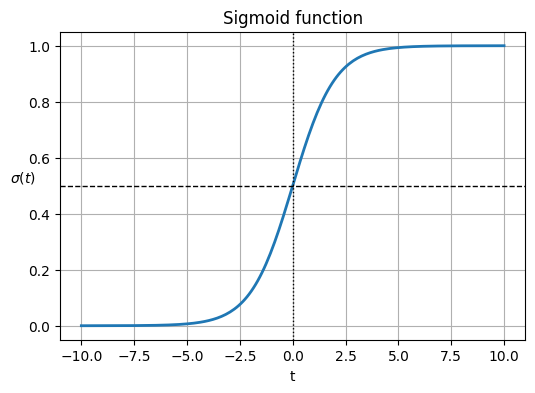

In [101]:
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

x = np.linspace(-10, 10, 200)
plt.figure(figsize=(6, 4))
plt.plot(x, sigmoid(x), linewidth=2)
plt.axhline(0.5, color="k", linestyle="--", linewidth=1)
plt.axvline(0, color="k", linestyle=":", linewidth=1)
plt.xlabel("t")
plt.ylabel(r"$\sigma(t)$", rotation=0)
plt.title("Sigmoid function")
plt.grid()
plt.show()

In [102]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
list(iris.feature_names), iris.target_names

(['sepal length (cm)',
  'sepal width (cm)',
  'petal length (cm)',
  'petal width (cm)'],
 array(['setosa', 'versicolor', 'virginica'], dtype='<U10'))

In [103]:
from sklearn.linear_model import LogisticRegression

X = iris.data[["petal width (cm)"]].values
y = (iris.target == 2).astype(int)   # Iris-Virginica면 1, 아니면 0

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X, y)

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)

decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0]
decision_boundary

np.float64(1.6606606606606606)

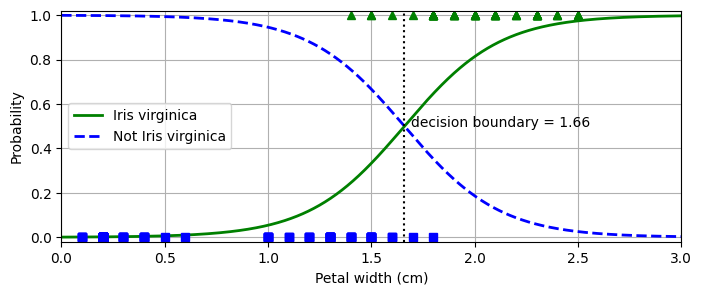

In [104]:
plt.figure(figsize=(8, 3))
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris virginica")
plt.plot(X[y == 0], y[y == 0], "bs")
plt.plot(X[y == 1], y[y == 1], "g^")
plt.axvline(decision_boundary, color="k", linestyle=":", linewidth=1.5)
plt.text(decision_boundary + 0.03, 0.5, f"decision boundary = {decision_boundary:.2f}")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend(loc="center left")
plt.axis([0, 3, -0.02, 1.02])
plt.grid()
plt.show()


In [105]:
log_reg.predict([[1.7]]), log_reg.predict_proba([[1.7]])


(array([1]), array([[0.45713982, 0.54286018]]))

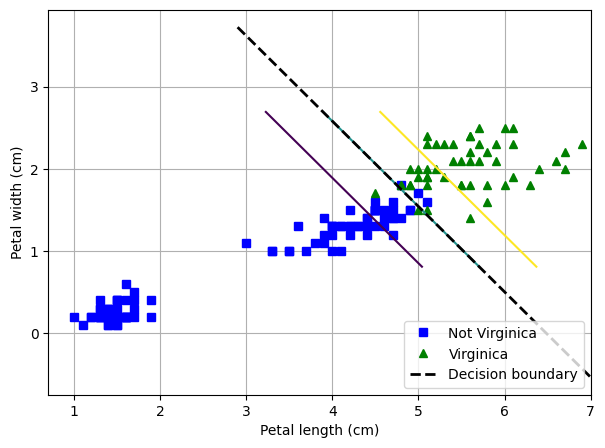

In [106]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2).astype(int)

log_reg_2d = LogisticRegression(C=2, random_state=42)
log_reg_2d.fit(X, y)

x0, x1 = np.meshgrid(
    np.linspace(2.9, 7, 300),
    np.linspace(0.8, 2.7, 300),
)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_proba = log_reg_2d.predict_proba(X_new)[:, 1].reshape(x0.shape)

a, b = log_reg_2d.coef_[0]
c = log_reg_2d.intercept_[0]
boundary = -(a * x0 + c) / b

plt.figure(figsize=(7, 5))
plt.plot(X[y == 0, 0], X[y == 0, 1], "bs", label="Not Virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "g^", label="Virginica")
plt.contour(x0, x1, y_proba, levels=[0.1, 0.5, 0.9], linewidths=1.5)
plt.plot(x0[0], boundary[0], "k--", linewidth=2, label="Decision boundary")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [107]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target

softmax_reg = LogisticRegression(C=30, random_state=42)
softmax_reg.fit(X, y)

softmax_reg.predict([[5, 2]]), softmax_reg.predict_proba([[5, 2]])


(array([2]), array([[2.08408710e-08, 2.85939761e-02, 9.71406003e-01]]))

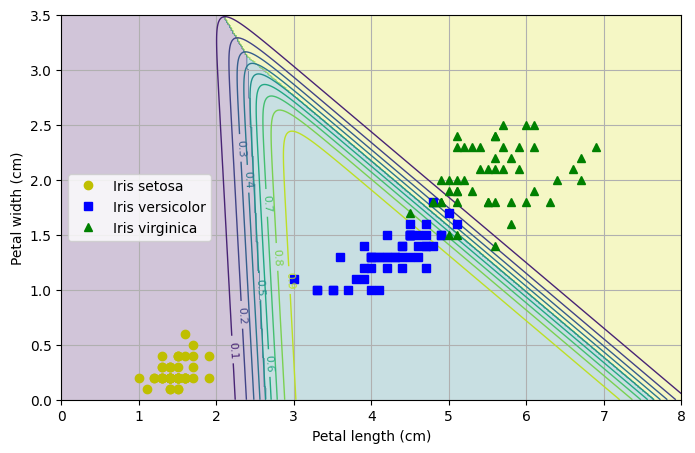

In [108]:
x0, x1 = np.meshgrid(
    np.linspace(0, 8, 400),
    np.linspace(0, 3.5, 400),
)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = softmax_reg.predict(X_new).reshape(x0.shape)
y_proba = softmax_reg.predict_proba(X_new)

plt.figure(figsize=(8, 5))
plt.contourf(x0, x1, y_predict, alpha=0.25)
contour = plt.contour(x0, x1, y_proba[:, 1].reshape(x0.shape), levels=10, linewidths=1)
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.legend(loc="center left")
plt.grid()
plt.show()


12버12번

In [109]:
np.random.seed(42)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris.target.values if hasattr(iris.target, "values") else iris.target

# train / valid split
rnd_idx = np.random.permutation(len(X))
train_size = int(len(X) * 0.8)
train_idx, valid_idx = rnd_idx[:train_size], rnd_idx[train_size:]
X_train, X_valid = X[train_idx], X[valid_idx]
y_train, y_valid = y[train_idx], y[valid_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

X_train_b = add_dummy_feature(X_train_scaled)
X_valid_b = add_dummy_feature(X_valid_scaled)

n_inputs = X_train_b.shape[1]
n_outputs = len(np.unique(y))

Y_train_one_hot = np.eye(n_outputs)[y_train]
Y_valid_one_hot = np.eye(n_outputs)[y_valid]

Theta = np.random.randn(n_inputs, n_outputs) * 0.01
eta = 0.1
n_epochs = 5000
alpha = 0.01
best_loss = np.inf
best_theta = None
patience = 20
patience_counter = 0
train_losses = []
valid_losses = []


def softmax(logits):
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    return exp / exp.sum(axis=1, keepdims=True)


def cross_entropy(proba, Y, Theta, alpha):
    eps = 1e-12
    data_loss = -np.mean(np.sum(Y * np.log(proba + eps), axis=1))
    reg_loss = alpha * np.sum(Theta[1:] ** 2) / 2
    return data_loss + reg_loss


for epoch in range(n_epochs):
    logits = X_train_b @ Theta
    proba = softmax(logits)
    gradients = (X_train_b.T @ (proba - Y_train_one_hot)) / len(X_train_b)
    gradients[1:] += alpha * Theta[1:]
    Theta -= eta * gradients

    train_loss = cross_entropy(softmax(X_train_b @ Theta), Y_train_one_hot, Theta, alpha)
    valid_loss = cross_entropy(softmax(X_valid_b @ Theta), Y_valid_one_hot, Theta, alpha)
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    if valid_loss < best_loss:
        best_loss = valid_loss
        best_theta = Theta.copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Theta = best_theta
valid_pred = np.argmax(softmax(X_valid_b @ Theta), axis=1)
valid_acc = (valid_pred == y_valid).mean()

best_loss, valid_acc


(np.float64(0.2851623913252596), np.float64(0.9666666666666667))

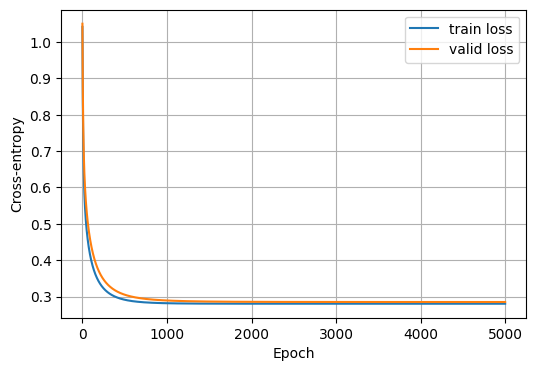

In [110]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="train loss")
plt.plot(valid_losses, label="valid loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy")
plt.legend()
plt.grid()
plt.show()


In [111]:
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = iris["target"].values

In [112]:
X_with_bias = np.c_[np.ones(len(X)), X]

In [113]:
test_ratio = 0.2
validation_ratio = 0.2
total_size = len(X_with_bias)

test_size = int(total_size * test_ratio)
validation_size = int(total_size * validation_ratio)
train_size = total_size - test_size - validation_size

np.random.seed(42)
rnd_indices = np.random.permutation(total_size)

X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]

X_valid = X_with_bias[rnd_indices[train_size:-test_size]]
y_valid = y[rnd_indices[train_size:-test_size]]

X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

In [114]:
def to_one_hot(y):
    return np.diag(np.ones(y.max() + 1))[y]

y_train[:10]

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

In [115]:
to_one_hot(y_train[:10])

array([[0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [116]:
Y_train_one_hot = to_one_hot(y_train)
Y_valid_one_hot = to_one_hot(y_valid)
Y_test_one_hot = to_one_hot(y_test)

In [117]:
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)

X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std

In [118]:
def softmax(logits):
    exps = np.exp(logits)
    exp_sums = exps.sum(axis=1, keepdims=True)
    return exps / exp_sums

In [119]:
n_inputs = X_train.shape[1]          # == 3 (2개의 특성과 편향)
n_outputs = len(np.unique(y_train))  # == 3 (3개의 붓꽃 클래스)

In [120]:
eta = 0.5
n_epochs = 5001
m = len(X_train)
epsilon = 1e-5

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)

    if epoch % 1000 == 0:
        Y_proba_valid = softmax(X_valid @ Theta)
        xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
        print(epoch, xentropy_losses.sum(axis=1).mean())

    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    Theta = Theta - eta * gradients

0 3.7085808486476917
1000 0.14519367480830644
2000 0.1301309575504088
3000 0.12009639326384539
4000 0.11372961364786884
5000 0.11002459532472425


In [121]:
Theta

array([[ 0.41931626,  6.11112089, -5.52429876],
       [-6.53054533, -0.74608616,  8.33137102],
       [-5.28115784,  0.25152675,  6.90680425]])

In [122]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

In [123]:
eta = 0.5
n_epochs = 50001
m = len(X_train)
epsilon = 1e-5
C = 100
best_loss = np.inf

np.random.seed(42)
Theta = np.random.randn(n_inputs, n_outputs)

for epoch in range(n_epochs):
    logits = X_train @ Theta
    Y_proba = softmax(logits)
    Y_proba_valid = softmax(X_valid @ Theta)

    xentropy_losses = -(Y_valid_one_hot * np.log(Y_proba_valid + epsilon))
    l2_loss = 1 / 2 * (Theta[1:] ** 2).sum()
    total_loss = xentropy_losses.sum(axis=1).mean() + 1 / C * l2_loss

    if epoch % 1000 == 0:
        print(epoch, total_loss.round(4))

    if total_loss < best_loss:
        best_loss = total_loss
    else:
        print(epoch - 1, best_loss.round(4))
        print(epoch, total_loss.round(4), "조기 종료!")
        break

    error = Y_proba - Y_train_one_hot
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), 1 / C * Theta[1:]]
    Theta = Theta - eta * gradients

0 3.7372
281 0.3256
282 0.3256 조기 종료!


In [124]:
logits = X_valid @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

In [125]:
logits = X_test @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

accuracy_score = (y_predict == y_test).mean()
accuracy_score

np.float64(0.9666666666666667)